# 🏛️ Sistem Case-Based Reasoning (CBR)
## Analisis Putusan Pengadilan – Perkara Perdata Agama
### Mata Kuliah: Penalaran Komputer | UMM Informatika 2025/2026

---
Notebook ini mengimplementasikan siklus CBR lengkap:
1. **Tahap 1** – Membangun Case Base (Preprocessing)
2. **Tahap 2** – Case Representation (Metadata & Feature Engineering)
3. **Tahap 3** – Case Retrieval (TF-IDF + SVM / Cosine Similarity)
4. **Tahap 4** – Case Solution Reuse (Prediksi Solusi)
5. **Tahap 5** – Model Evaluation (Accuracy, Precision, Recall, F1)

**Domain Perkara:** Perdata Agama (Gugatan Cerai, Harta Bersama, Waris, dll.)

**Sumber Data:** Direktori Putusan Mahkamah Agung RI (putusan.mahkamahagung.go.id)

---
# ☁️ Google Drive Integration
> **Tujuan:** Mount Google Drive dan buat struktur folder proyek CBR secara otomatis di Drive

Jalankan sel di bawah **sebelum** sel-sel lainnya agar semua output tersimpan ke Google Drive.

**Struktur folder yang akan dibuat di Drive:**
```
MyDrive/
└── CBR_Perdata_Agama/
    ├── data/
    │   ├── pdf/          ← Letakkan 30 PDF putusan di sini
    │   ├── raw/          ← Teks bersih hasil ekstraksi
    │   ├── processed/    ← cases.csv & cases.json
    │   ├── eval/         ← Metrik evaluasi
    │   └── results/      ← Prediksi & chart
    └── logs/             ← Log pembersihan
```


In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║         PATCH GOOGLE DRIVE – CBR Perdata Agama                 ║
# ║  Jalankan sel ini PERTAMA KALI sebelum sel-sel lainnya.        ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, sys
from pathlib import Path

# ══════════════════════════════════════════════════════════════════
#  ▶▶  GANTI PATH DI BAWAH INI SESUAI LOKASI FOLDER DI DRIVE  ◀◀
#  Contoh: '/content/drive/MyDrive/CBR_Perdata_Agama'
#          '/content/drive/MyDrive/Kuliah/Semester6/CBR_PA'
GDRIVE_BASE = '/content/drive/MyDrive/CBRdimas'
# ══════════════════════════════════════════════════════════════════

# ── 1. Deteksi environment (Colab vs lokal) ───────────────────────────────────
IN_COLAB = 'google.colab' in sys.modules or 'COLAB_BACKEND_URL' in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print('✅ Google Drive berhasil di-mount')
else:
    # Fallback lokal: pakai subfolder gdrive_mock agar tidak bercampur dengan project
    GDRIVE_BASE = str(Path('./gdrive_mock') / Path(GDRIVE_BASE).name)
    print('ℹ️  Bukan Colab – menggunakan folder lokal sebagai simulasi Google Drive:')
    print(f'   {Path(GDRIVE_BASE).resolve()}')

# ── 2. Buat path turunan dari GDRIVE_BASE ────────────────────────────────────
GDRIVE_PROJECT = Path(GDRIVE_BASE)

GDRIVE_DIRS = {
    'pdf'      : GDRIVE_PROJECT / 'data' / 'pdf',
    'raw'      : GDRIVE_PROJECT / 'data' / 'raw',
    'processed': GDRIVE_PROJECT / 'data' / 'processed',
    'eval'     : GDRIVE_PROJECT / 'data' / 'eval',
    'results'  : GDRIVE_PROJECT / 'data' / 'results',
    'logs'     : GDRIVE_PROJECT / 'logs',
}

print(f'\n📂 Membuat struktur folder di: {GDRIVE_PROJECT}')
for key, d in GDRIVE_DIRS.items():
    d.mkdir(parents=True, exist_ok=True)
    print(f'   ✅ {d}')

# ── 3. Override BASE_DIR & semua path utama ──────────────────────────────────
#    Variabel berikut akan dipakai oleh seluruh sel di bawahnya.
#    Pastikan sel ini dijalankan SEBELUM sel "Inisialisasi Struktur Folder".
BASE_DIR   = GDRIVE_PROJECT
DATA_RAW   = GDRIVE_DIRS['raw']
DATA_PROC  = GDRIVE_DIRS['processed']
DATA_EVAL  = GDRIVE_DIRS['eval']
DATA_RES   = GDRIVE_DIRS['results']
LOGS_DIR   = GDRIVE_DIRS['logs']
PDF_DIR    = GDRIVE_DIRS['pdf']

print(f'\n🎯 Path proyek berhasil diarahkan ke:')
print(f'   BASE_DIR  → {BASE_DIR}')
print(f'   PDF_DIR   → {PDF_DIR}')
print(f'   DATA_PROC → {DATA_PROC}')
print(f'   DATA_RES  → {DATA_RES}')

print('\n' + '─'*60)
print('📌 PETUNJUK SELANJUTNYA:')
print(f'   1. Upload 30 file PDF putusan ke folder:')
print(f'      {PDF_DIR}')
print(f'   2. Lanjutkan jalankan sel-sel berikutnya seperti biasa.')
print('─'*60)


Mounted at /content/drive
✅ Google Drive berhasil di-mount

📂 Membuat struktur folder di: /content/drive/MyDrive/CBRdimas
   ✅ /content/drive/MyDrive/CBRdimas/data/pdf
   ✅ /content/drive/MyDrive/CBRdimas/data/raw
   ✅ /content/drive/MyDrive/CBRdimas/data/processed
   ✅ /content/drive/MyDrive/CBRdimas/data/eval
   ✅ /content/drive/MyDrive/CBRdimas/data/results
   ✅ /content/drive/MyDrive/CBRdimas/logs

🎯 Path proyek berhasil diarahkan ke:
   BASE_DIR  → /content/drive/MyDrive/CBRdimas
   PDF_DIR   → /content/drive/MyDrive/CBRdimas/data/pdf
   DATA_PROC → /content/drive/MyDrive/CBRdimas/data/processed
   DATA_RES  → /content/drive/MyDrive/CBRdimas/data/results

────────────────────────────────────────────────────────────
📌 PETUNJUK SELANJUTNYA:
   1. Upload 30 file PDF putusan ke folder:
      /content/drive/MyDrive/CBRdimas/data/pdf
   2. Lanjutkan jalankan sel-sel berikutnya seperti biasa.
────────────────────────────────────────────────────────────


## ⚙️ Instalasi & Import Library

In [2]:
# Install dependencies (jalankan sekali)
import subprocess, sys

packages = [
    'pdfminer.six', 'beautifulsoup4', 'requests',
    'scikit-learn', 'pandas', 'numpy',
    'matplotlib', 'seaborn', 'openpyxl'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ Semua library berhasil diinstall!')

✅ Semua library berhasil diinstall!


In [3]:
# ── Import Umum ──────────────────────────────────────────────────────────────
import os, re, json, logging, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
warnings.filterwarnings('ignore')

# ── NLP & ML ─────────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity

# ── PDF & HTML Parsing ───────────────────────────────────────────────────────
from pdfminer.high_level import extract_text as pdf_extract_text
from bs4 import BeautifulSoup

print('✅ Semua import berhasil!')
print(f'   Pandas   : {pd.__version__}')
print(f'   Numpy    : {np.__version__}')
print(f'   Sklearn  : {__import__("sklearn").__version__}')

✅ Semua import berhasil!
   Pandas   : 2.2.2
   Numpy    : 2.0.2
   Sklearn  : 1.6.1


## 📁 Inisialisasi Struktur Folder & Logging

In [4]:
# ── Struktur Direktori Proyek ─────────────────────────────────────────────────
# Jika sel PATCH GOOGLE DRIVE sudah dijalankan, variabel BASE_DIR s.d. PDF_DIR
# sudah terdefinisi dan menunjuk ke Google Drive – blok ini hanya menjadi fallback
# agar notebook tetap bisa berjalan tanpa Drive (misalnya di Jupyter lokal).

from pathlib import Path

try:
    BASE_DIR   # sudah di-set oleh sel Patch → tidak perlu override
    print('ℹ️  Menggunakan path dari Patch Google Drive:')
except NameError:
    # Belum ada patch → gunakan folder lokal
    BASE_DIR   = Path('.')
    DATA_RAW   = BASE_DIR / 'data' / 'raw'
    DATA_PROC  = BASE_DIR / 'data' / 'processed'
    DATA_EVAL  = BASE_DIR / 'data' / 'eval'
    DATA_RES   = BASE_DIR / 'data' / 'results'
    LOGS_DIR   = BASE_DIR / 'logs'
    PDF_DIR    = BASE_DIR / 'data' / 'pdf'
    print('ℹ️  Patch Drive tidak dijalankan – menggunakan folder lokal:')

for d in [DATA_RAW, DATA_PROC, DATA_EVAL, DATA_RES, LOGS_DIR, PDF_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Setup Logging ─────────────────────────────────────────────────────────────
import logging
logging.basicConfig(
    filename=str(LOGS_DIR / 'cleaning.log'),
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger('CBR_Logger')

print('✅ Struktur folder berhasil dibuat:')
for d in [DATA_RAW, DATA_PROC, DATA_EVAL, DATA_RES, LOGS_DIR, PDF_DIR]:
    print(f'   📂 {d}')


ℹ️  Menggunakan path dari Patch Google Drive:
✅ Struktur folder berhasil dibuat:
   📂 /content/drive/MyDrive/CBRdimas/data/raw
   📂 /content/drive/MyDrive/CBRdimas/data/processed
   📂 /content/drive/MyDrive/CBRdimas/data/eval
   📂 /content/drive/MyDrive/CBRdimas/data/results
   📂 /content/drive/MyDrive/CBRdimas/logs
   📂 /content/drive/MyDrive/CBRdimas/data/pdf


---
# 📌 TAHAP 1 – Membangun Case Base
> **Tujuan:** Mengumpulkan & membersihkan corpus putusan Perdata Agama

**Cara penggunaan:**
- Letakkan 30 file PDF putusan ke folder `data/pdf/`
- Nama file bebas, misal: `001_cerai_gugat.pdf`, `002_harta_bersama.pdf`, dst.
- Jalankan sel di bawah untuk ekstraksi & pembersihan otomatis

In [5]:
# ── Fungsi Ekstraksi Teks dari PDF ───────────────────────────────────────────
def extract_text_from_pdf(pdf_path: Path) -> str:
    """Ekstrak plain text dari file PDF putusan."""
    try:
        text = pdf_extract_text(str(pdf_path))
        return text if text else ''
    except Exception as e:
        logger.error(f'Gagal ekstrak {pdf_path.name}: {e}')
        return ''


def extract_text_from_html(html_path: Path) -> str:
    """Ekstrak plain text dari file HTML putusan."""
    try:
        soup = BeautifulSoup(html_path.read_text(encoding='utf-8', errors='ignore'), 'html.parser')
        return soup.get_text(separator=' ')
    except Exception as e:
        logger.error(f'Gagal ekstrak HTML {html_path.name}: {e}')
        return ''


# ── Fungsi Pembersihan Teks ───────────────────────────────────────────────────
HEADER_FOOTER_PATTERNS = [
    r'halaman\s*\d+\s*(dari|of)\s*\d+',
    r'mahkamah\s+agung\s+republik\s+indonesia',
    r'direktori\s+putusan',
    r'putusan\.mahkamahagung\.go\.id',
    r'disclaimer[\s\S]*?digunakan',
    r'\bhalaman\b\s*\d+',
    r'\d+\s*/\s*\d+\s*(hal|hlm)',
    r'demi\s+keadilan\s+berdasarkan\s+ketuhanan\s+yang\s+maha\s+esa',
]

def clean_text(raw_text: str) -> str:
    """Bersihkan teks: hapus header/footer, normalisasi spasi & karakter."""
    text = raw_text.lower()
    # Hapus pola header/footer
    for pattern in HEADER_FOOTER_PATTERNS:
        text = re.sub(pattern, ' ', text, flags=re.IGNORECASE)
    # Hapus karakter non-alfanumerik kecuali tanda baca penting
    text = re.sub(r'[^\w\s.,;:\-/()]', ' ', text)
    # Normalisasi spasi
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def validate_text(text: str, min_ratio: float = 0.8) -> bool:
    """Validasi: minimal 80% karakter alfanumerik (bukan whitespace acak)."""
    if len(text) < 200:
        return False
    alpha_count = sum(1 for c in text if c.isalnum() or c.isspace())
    return (alpha_count / len(text)) >= min_ratio


print('✅ Fungsi preprocessing berhasil didefinisikan!')

✅ Fungsi preprocessing berhasil didefinisikan!


In [8]:
# ── Proses Semua File PDF ─────────────────────────────────────────────────────
pdf_files = sorted(PDF_DIR.glob('*.pdf'))
html_files = sorted(PDF_DIR.glob('*.html'))
all_files = pdf_files + html_files

print(f'📄 Ditemukan {len(pdf_files)} file PDF & {len(html_files)} file HTML')
print(f'   Total: {len(all_files)} dokumen\n')

if len(all_files) == 0:
    print('⚠️  PERHATIAN: Belum ada file di folder data/pdf/')
    print('   → Letakkan 30 file PDF putusan di folder tersebut, lalu jalankan ulang sel ini.')
else:
    raw_corpus = []   # list of dict
    valid_count = 0
    invalid_list = []

    for idx, fpath in enumerate(all_files, start=1):
        case_id = f'case_{idx:03d}'

        # Ekstraksi
        if fpath.suffix.lower() == '.pdf':
            raw_text = extract_text_from_pdf(fpath)
        else:
            raw_text = extract_text_from_html(fpath)

        # Pembersihan
        clean = clean_text(raw_text)

        # Validasi
        is_valid = validate_text(clean)
        status = '✅' if is_valid else '⚠️'

        if is_valid:
            valid_count += 1
            logger.info(f'[OK] {case_id} | {fpath.name} | chars={len(clean)}')
        else:
            invalid_list.append(fpath.name)
            logger.warning(f'[INVALID] {case_id} | {fpath.name} | chars={len(clean)}')

        # Simpan ke /data/raw/
        out_path = DATA_RAW / f'{case_id}.txt'
        out_path.write_text(clean, encoding='utf-8')

        raw_corpus.append({
            'case_id'   : case_id,
            'source_file': fpath.name,
            'text_clean': clean,
            'char_count': len(clean),
            'word_count': len(clean.split()),
            'is_valid'  : is_valid
        })

        print(f'{status} [{case_id}] {fpath.name[:50]:<50} | {len(clean):>8} chars')

    df_raw = pd.DataFrame(raw_corpus)
    print(f'\n📊 Ringkasan:')
    print(f'   Total dokumen  : {len(df_raw)}')
    print(f'   Valid (≥80%)   : {valid_count}')
    print(f'   Tidak valid    : {len(invalid_list)}')
    if invalid_list:
        print(f'   File bermasalah: {invalid_list}')
    print(f'\n✅ Teks disimpan di: {DATA_RAW}')
    print(f'📋 Log tersimpan di: {LOGS_DIR}/cleaning.log')

📄 Ditemukan 30 file PDF & 0 file HTML
   Total: 30 dokumen

✅ [case_001] putusan_101_k_ag_2026_20260615131538.pdf           |    18855 chars
✅ [case_002] putusan_102_k_ag_2026_20260615131551.pdf           |    14607 chars
✅ [case_003] putusan_109_k_ag_2026_20260615130107.pdf           |    28961 chars
✅ [case_004] putusan_111_k_ag_2026_20260615131232.pdf           |    27203 chars
✅ [case_005] putusan_117_k_ag_2026_20260615130148.pdf           |    19227 chars
✅ [case_006] putusan_118_k_ag_2026_20260612164120.pdf           |    18782 chars
✅ [case_007] putusan_119_k_ag_2026_20260613174115.pdf           |    18690 chars
✅ [case_008] putusan_122_k_ag_2026_20260614093129.pdf           |    35584 chars
✅ [case_009] putusan_124_k_ag_2026_20260615130402.pdf           |    17824 chars
✅ [case_010] putusan_137_k_ag_2026_20260615130929.pdf           |    52926 chars
✅ [case_011] putusan_140_k_ag_2026_20260615131121.pdf           |    31353 chars
✅ [case_012] putusan_145_k_ag_2026_20260615130040

---
# 📌 TAHAP 2 – Case Representation
> **Tujuan:** Representasikan setiap putusan dalam struktur data terorganisir

Ekstraksi metadata penting + feature engineering dari teks putusan

In [9]:
# ── Fungsi Ekstraksi Metadata ─────────────────────────────────────────────────

def extract_no_perkara(text: str) -> str:
    """Ekstrak nomor perkara dari teks putusan."""
    patterns = [
        r'nomor\s*[:\.]?\s*([\d/a-z\.]+/pdt\.g/[\d]{4}/pa[/\w]*)',
        r'nomor\s*[:\.]?\s*([\d/a-z\.]+/[\w]+/[\d]{4}/[\w]+)',
        r'no\.?\s*perkara\s*[:\.]?\s*([\d/\w\.]+)',
        r'([\d]+/pdt\.?[\w]*/[\d]{4}/pa[\w]*)',
    ]
    for pat in patterns:
        m = re.search(pat, text, re.IGNORECASE)
        if m:
            return m.group(1).strip()
    return 'TIDAK_DITEMUKAN'


def extract_tanggal(text: str) -> str:
    """Ekstrak tanggal putusan."""
    bulan = (
        'januari|februari|maret|april|mei|juni|juli|agustus|'
        'september|oktober|november|desember'
    )
    patterns = [
        rf'(\d{{1,2}})\s+({bulan})\s+(\d{{4}})',
        r'(\d{1,2})[/\-](\d{1,2})[/\-](\d{4})',
        r'tanggal\s+(\d{1,2})\s+([a-z]+)\s+(\d{4})',
    ]
    for pat in patterns:
        m = re.search(pat, text, re.IGNORECASE)
        if m:
            return ' '.join(m.groups())
    return 'TIDAK_DITEMUKAN'


def extract_jenis_perkara(text: str) -> str:
    """Klasifikasi jenis perkara perdata agama."""
    jenis_map = {
        'cerai gugat'     : ['cerai gugat', 'gugatan cerai', 'penggugat menggugat cerai'],
        'cerai talak'     : ['cerai talak', 'talak', 'pemohon memohon talak'],
        'harta bersama'   : ['harta bersama', 'harta gono gini', 'pembagian harta'],
        'waris'           : ['waris', 'warisan', 'pewaris', 'ahli waris', 'harta warisan'],
        'hadhanah'        : ['hadhanah', 'hak asuh', 'pengasuhan anak', 'pemeliharaan anak'],
        'nafkah'          : ['nafkah', 'nafkah iddah', 'nafkah mut'],
        'isbat nikah'     : ['isbat nikah', 'itsbat nikah', 'pengesahan nikah'],
        'dispensasi nikah': ['dispensasi nikah', 'dispensasi kawin'],
    }
    for jenis, keywords in jenis_map.items():
        for kw in keywords:
            if kw in text:
                return jenis
    return 'perdata agama lainnya'


def extract_pasal(text: str) -> str:
    """Ekstrak pasal-pasal yang digunakan dalam putusan."""
    patterns = [
        r'pasal\s+\d+[\s,a-z]*(?:ayat\s+\(\d+\))?(?:\s+(?:dan|jo\.?)\s+pasal\s+\d+)*',
        r'uu\s+no\.?\s*\d+\s+tahun\s+\d+',
        r'undang.undang\s+nomor\s+\d+\s+tahun\s+\d+',
    ]
    found = []
    for pat in patterns:
        matches = re.findall(pat, text[:3000], re.IGNORECASE)
        found.extend(matches)
    unique = list(dict.fromkeys([m.strip() for m in found[:5]]))
    return ' | '.join(unique) if unique else 'TIDAK_DITEMUKAN'


def extract_pihak(text: str) -> str:
    """Ekstrak nama pihak penggugat/pemohon dan tergugat/termohon."""
    patterns = [
        r'(penggugat|pemohon)\s*[:\.]?\s*([A-Za-z\s]+?)(?=\s*(?:vs|lawan|melawan|tergugat|termohon|NIK|umur|bin|binti|,|\n))',
        r'antara\s+(.{5,40})\s+(?:vs\.?|lawan|melawan)\s+(.{5,40})',
    ]
    for pat in patterns:
        m = re.search(pat, text[:2000], re.IGNORECASE)
        if m:
            groups = [g.strip() for g in m.groups() if g]
            if len(groups) >= 2:
                return f'{groups[-2]} vs {groups[-1]}'
            return groups[0]
    return 'TIDAK_DITEMUKAN'


def extract_amar_putusan(text: str) -> str:
    """Ekstrak amar putusan sebagai solusi kasus."""
    patterns = [
        r'(?:mengadili|amar\s+putusan)[\s\S]{0,200}?((?:mengabulkan|menolak|menyatakan)[\s\S]{0,500}?)(?:demikian|ditetapkan|ditandatangani)',
        r'(mengabulkan\s+(?:gugatan|permohonan)[\s\S]{0,300})',
        r'(menolak\s+(?:gugatan|permohonan)[\s\S]{0,200})',
    ]
    for pat in patterns:
        m = re.search(pat, text, re.IGNORECASE)
        if m:
            amar = m.group(1).strip()
            return ' '.join(amar.split())[:500]  # max 500 char
    # Fallback: ambil 300 kata terakhir
    return ' '.join(text.split()[-300:])


def extract_ringkasan_fakta(text: str) -> str:
    """Ekstrak ringkasan fakta / posita dari teks."""
    patterns = [
        r'(?:duduk\s+perkara|posita|fakta\s+hukum)[\s\S]{0,100}([\s\S]{200,600}?)(?:pertimbangan|mengadili|menimbang)',
        r'(?:bahwa|yang\s+bertanda\s+tangan)[\s\S]{0,50}([\s\S]{200,500}?)(?:berdasarkan|dengan\s+ini|oleh\s+karena)',
    ]
    for pat in patterns:
        m = re.search(pat, text, re.IGNORECASE)
        if m:
            ringkasan = m.group(1).strip()
            return ' '.join(ringkasan.split())[:400]
    return ' '.join(text.split()[:150])  # Fallback: 150 kata pertama


def classify_label(jenis: str) -> str:
    """Buat label klasifikasi sederhana untuk evaluasi model."""
    if 'cerai' in jenis:
        return 'cerai'
    elif 'waris' in jenis:
        return 'waris'
    elif 'harta' in jenis:
        return 'harta_bersama'
    elif 'hadhanah' in jenis or 'nafkah' in jenis:
        return 'hadhanah_nafkah'
    else:
        return 'lainnya'


print('✅ Fungsi ekstraksi metadata berhasil didefinisikan!')

✅ Fungsi ekstraksi metadata berhasil didefinisikan!


In [14]:
# ── Proses Case Representation ────────────────────────────────────────────────
txt_files = sorted(DATA_RAW.glob('*.txt'))
print(f'📂 Memproses {len(txt_files)} file teks dari {DATA_RAW}\n')

cases_data = []

if not txt_files:
    print(f'⚠️  Tidak ditemukan file teks di {DATA_RAW}. Pastikan sel sebelumnya telah dijalankan dan berhasil membuat file .txt.')
else:
    for txt_file in txt_files:
        text = txt_file.read_text(encoding='utf-8')
        case_id = txt_file.stem

        no_perkara   = extract_no_perkara(text)
        tanggal      = extract_tanggal(text)
        jenis        = extract_jenis_perkara(text)
        pasal        = extract_pasal(text)
        pihak        = extract_pihak(text)
        ringkasan    = extract_ringkasan_fakta(text)
        amar         = extract_amar_putusan(text)
        label        = classify_label(jenis)
        word_count   = len(text.split())

        cases_data.append({
            'case_id'         : case_id,
            'no_perkara'      : no_perkara,
            'tanggal'         : tanggal,
            'jenis_perkara'   : jenis,
            'label'           : label,
            'pasal'           : pasal,
            'pihak'           : pihak,
            'ringkasan_fakta' : ringkasan,
            'amar_putusan'    : amar,
            'word_count'      : word_count,
            'text_full'       : text[:2000]   # Simpan 2000 karakter pertama
        })

        print(f'✅ {case_id} | {jenis:<25} | {word_count:>6} kata | label: {label}')

df_cases = pd.DataFrame(cases_data)

# ── Simpan ke CSV & JSON ──────────────────────────────────────────────────────
csv_path  = DATA_PROC / 'cases.csv'
json_path = DATA_PROC / 'cases.json'

if not df_cases.empty:
    df_cases.to_csv(csv_path, index=False, encoding='utf-8-sig')
    df_cases.to_json(json_path, orient='records', force_ascii=False, indent=2)

    print(f'\n✅ Case representation selesai!')
    print(f'   CSV  → {csv_path}')
    print(f'   JSON → {json_path}')
    print(f'\n📊 Distribusi label:')
    print(df_cases['label'].value_counts().to_string())
else:
    print(f'\n❌ Case representation tidak dapat dilakukan karena tidak ada file teks yang diproses.')
    print(f'   DataFrame df_cases kosong.')


📂 Memproses 30 file teks dari /content/drive/MyDrive/CBRdimas/data/raw

✅ case_001 | hadhanah                  |   2568 kata | label: hadhanah_nafkah
✅ case_002 | cerai gugat               |   1983 kata | label: cerai
✅ case_003 | harta bersama             |   4048 kata | label: harta_bersama
✅ case_004 | harta bersama             |   3707 kata | label: harta_bersama
✅ case_005 | waris                     |   2667 kata | label: waris
✅ case_006 | perdata agama lainnya     |   2557 kata | label: lainnya
✅ case_007 | waris                     |   2568 kata | label: waris
✅ case_008 | harta bersama             |   4914 kata | label: harta_bersama
✅ case_009 | harta bersama             |   2453 kata | label: harta_bersama
✅ case_010 | harta bersama             |   7496 kata | label: harta_bersama
✅ case_011 | harta bersama             |   4237 kata | label: harta_bersama
✅ case_012 | harta bersama             |   2815 kata | label: harta_bersama
✅ case_013 | harta bersama             |   3

In [11]:
# ── Tampilkan Preview Dataset ─────────────────────────────────────────────────
print('\n📋 Preview 5 kasus pertama:')
display(df_cases[['case_id','no_perkara','tanggal','jenis_perkara','label','word_count']].head())

# ── Feature Engineering ───────────────────────────────────────────────────────
print('\n🔧 Feature Engineering...')
df_cases['text_length']    = df_cases['text_full'].apply(len)
df_cases['fakta_length']   = df_cases['ringkasan_fakta'].apply(len)
df_cases['amar_length']    = df_cases['amar_putusan'].apply(len)
df_cases['has_waris']      = df_cases['text_full'].str.contains('waris', case=False).astype(int)
df_cases['has_cerai']      = df_cases['text_full'].str.contains('cerai', case=False).astype(int)
df_cases['has_nafkah']     = df_cases['text_full'].str.contains('nafkah', case=False).astype(int)
df_cases['has_hadhanah']   = df_cases['text_full'].str.contains('hadhanah', case=False).astype(int)

# Update simpan dengan fitur tambahan
df_cases.to_csv(DATA_PROC / 'cases_features.csv', index=False, encoding='utf-8-sig')
print('✅ Feature engineering selesai! Disimpan ke cases_features.csv')


📋 Preview 5 kasus pertama:


,case_id,no_perkara,tanggal,jenis_perkara,label,word_count
0,case_001,1333/pdt.g/2025/pa,14 oktober 2025,hadhanah,hadhanah_nafkah,2568
1,case_002,1094/pdt.g/2025/pa,21 agustus 2025,cerai gugat,cerai,1983
2,case_003,3602/pdt.g/2024/pa,8 oktober 2025,harta bersama,harta_bersama,4048
3,case_004,287/pdt.g/2024/pa,6 april 2025,harta bersama,harta_bersama,3707
4,case_005,464/pdt.p/2025/pa,5 november 2025,waris,waris,2667



🔧 Feature Engineering...
✅ Feature engineering selesai! Disimpan ke cases_features.csv


---
# 📌 TAHAP 3 – Case Retrieval
> **Tujuan:** Temukan kasus lama yang paling mirip dengan query kasus baru

Menggunakan dua pendekatan:
- **TF-IDF + Cosine Similarity** → Retrieval berbasis statistik
- **TF-IDF + SVM / Naive Bayes** → Retrieval berbasis klasifikasi

In [12]:
# ── Persiapan Data ────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PROC / 'cases_features.csv')

# Gabungkan kolom teks untuk representasi vektor
df['text_combined'] = (
    df['ringkasan_fakta'].fillna('') + ' ' +
    df['amar_putusan'].fillna('') + ' ' +
    df['text_full'].fillna('')
)

print(f'📊 Total kasus: {len(df)}')
print(f'📊 Distribusi label:')
print(df['label'].value_counts().to_string())

# Encode label
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])
print(f'\n🏷️  Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

📊 Total kasus: 30
📊 Distribusi label:
label
harta_bersama      15
lainnya             6
waris               5
hadhanah_nafkah     3
cerai               1

🏷️  Label mapping: {'cerai': np.int64(0), 'hadhanah_nafkah': np.int64(1), 'harta_bersama': np.int64(2), 'lainnya': np.int64(3), 'waris': np.int64(4)}


In [15]:
# ── TF-IDF Vectorization ──────────────────────────────────────────────────────
print('🔄 Membuat TF-IDF Vectors...')

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_combined'])
print(f'✅ TF-IDF Matrix shape: {tfidf_matrix.shape}')
print(f'   (baris=dokumen, kolom=fitur/kata)')

# Simpan mapping case_id → index
case_index = {row['case_id']: idx for idx, row in df.iterrows()}
case_solutions = {row['case_id']: row['amar_putusan'] for _, row in df.iterrows()}

🔄 Membuat TF-IDF Vectors...
✅ TF-IDF Matrix shape: (30, 4728)
   (baris=dokumen, kolom=fitur/kata)


In [16]:
# ── Train/Test Split ──────────────────────────────────────────────────────────
X = tfidf_matrix
y = df['label_encoded'].values

# Check if stratification is possible (all classes must have at least 2 samples)
can_stratify = np.min(np.bincount(y)) >= 2 if len(y) > 0 else False
stratify_param = y if can_stratify else None

# 80:20 split
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index.tolist(),
    test_size=0.2, random_state=42, stratify=stratify_param
)

print(f'📊 Splitting Data (80:20):')
print(f'   Train : {X_train.shape[0]} dokumen')
print(f'   Test  : {X_test.shape[0]} dokumen')

📊 Splitting Data (80:20):
   Train : 24 dokumen
   Test  : 6 dokumen


In [17]:
# ── Model 1: SVM ──────────────────────────────────────────────────────────────
print('🤖 Training SVM...')
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

acc_svm  = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, average='weighted', zero_division=0)
rec_svm  = recall_score(y_test, y_pred_svm, average='weighted', zero_division=0)
f1_svm   = f1_score(y_test, y_pred_svm, average='weighted', zero_division=0)

print(f'\n📈 Hasil SVM:')
print(f'   Accuracy : {acc_svm:.4f}')
print(f'   Precision: {prec_svm:.4f}')
print(f'   Recall   : {rec_svm:.4f}')
print(f'   F1-Score : {f1_svm:.4f}')

# Get unique labels present in y_test and y_pred_svm to correctly match target_names
unique_labels_in_test_set = np.unique(np.concatenate((y_test, y_pred_svm)))
filtered_target_names_svm = [le.classes_[label_idx] for label_idx in unique_labels_in_test_set]

print(f'\n{classification_report(y_test, y_pred_svm, labels=unique_labels_in_test_set, target_names=filtered_target_names_svm, zero_division=0)}')

🤖 Training SVM...

📈 Hasil SVM:
   Accuracy : 0.5000
   Precision: 0.2500
   Recall   : 0.5000
   F1-Score : 0.3333

                 precision    recall  f1-score   support

hadhanah_nafkah       0.00      0.00      0.00         1
  harta_bersama       0.50      1.00      0.67         3
          waris       0.00      0.00      0.00         2

       accuracy                           0.50         6
      macro avg       0.17      0.33      0.22         6
   weighted avg       0.25      0.50      0.33         6



In [18]:
# ── Model 2: Naive Bayes ──────────────────────────────────────────────────────
print('🤖 Training Naive Bayes...')
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

acc_nb  = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, average='weighted', zero_division=0)
rec_nb  = recall_score(y_test, y_pred_nb, average='weighted', zero_division=0)
f1_nb   = f1_score(y_test, y_pred_nb, average='weighted', zero_division=0)

print(f'\n📈 Hasil Naive Bayes:')
print(f'   Accuracy : {acc_nb:.4f}')
print(f'   Precision: {prec_nb:.4f}')
print(f'   Recall   : {rec_nb:.4f}')
print(f'   F1-Score : {f1_nb:.4f}')

# Get unique labels present in y_test and y_pred_nb to correctly match target_names
unique_labels_in_test_set_nb = np.unique(np.concatenate((y_test, y_pred_nb)))
filtered_target_names_nb = [le.classes_[label_idx] for label_idx in unique_labels_in_test_set_nb]

print(f'\n{classification_report(y_test, y_pred_nb, labels=unique_labels_in_test_set_nb, target_names=filtered_target_names_nb, zero_division=0)}')

🤖 Training Naive Bayes...

📈 Hasil Naive Bayes:
   Accuracy : 0.5000
   Precision: 0.3000
   Recall   : 0.5000
   F1-Score : 0.3750

                 precision    recall  f1-score   support

hadhanah_nafkah       0.00      0.00      0.00         1
  harta_bersama       0.60      1.00      0.75         3
        lainnya       0.00      0.00      0.00         0
          waris       0.00      0.00      0.00         2

       accuracy                           0.50         6
      macro avg       0.15      0.25      0.19         6
   weighted avg       0.30      0.50      0.38         6



In [19]:
# ── Fungsi Retrieval (Cosine Similarity) ──────────────────────────────────────
def retrieve(query: str, k: int = 5) -> list:
    """
    Fungsi utama CBR Retrieval.
    Input : query string (deskripsi kasus baru)
    Output: list of (case_id, similarity_score)
    """
    # 1) Pre-process query
    query_clean = clean_text(query)

    # 2) Hitung vektor query
    query_vec = tfidf_vectorizer.transform([query_clean])

    # 3) Hitung cosine similarity dengan semua case vectors
    similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()

    # 4) Kembalikan top-k case_id beserta skor
    top_k_indices = similarities.argsort()[::-1][:k]
    results = [
        (df.iloc[i]['case_id'], float(similarities[i]))
        for i in top_k_indices
    ]
    return results


print('✅ Fungsi retrieve() berhasil didefinisikan!')

# ── Uji Fungsi Retrieve ───────────────────────────────────────────────────────
test_query = 'penggugat mengajukan gugatan cerai kepada tergugat karena perselisihan terus menerus sejak menikah harta bersama'
print(f'\n🔍 Query uji: "{test_query[:80]}..."')
print('\n📋 Top-5 kasus mirip:')
results = retrieve(test_query, k=5)
for rank, (case_id, score) in enumerate(results, 1):
    row = df[df['case_id'] == case_id].iloc[0]
    print(f'   #{rank} | {case_id} | skor: {score:.4f} | jenis: {row["jenis_perkara"]}')

✅ Fungsi retrieve() berhasil didefinisikan!

🔍 Query uji: "penggugat mengajukan gugatan cerai kepada tergugat karena perselisihan terus men..."

📋 Top-5 kasus mirip:
   #1 | case_026 | skor: 0.1227 | jenis: harta bersama
   #2 | case_009 | skor: 0.0875 | jenis: harta bersama
   #3 | case_012 | skor: 0.0785 | jenis: harta bersama
   #4 | case_019 | skor: 0.0775 | jenis: harta bersama
   #5 | case_022 | skor: 0.0586 | jenis: harta bersama


In [20]:
# ── Buat File Queries untuk Evaluasi ─────────────────────────────────────────
# 10 query uji + ground truth (sesuaikan case_id dengan dataset Anda)

sample_queries = []
for _, row in df.sample(min(10, len(df)), random_state=42).iterrows():
    # Gunakan ringkasan fakta sebagai query, dan label sebagai ground truth
    sample_queries.append({
        'query_id'       : f'q_{row["case_id"]}',
        'query_text'     : row['ringkasan_fakta'],
        'ground_truth_id': row['case_id'],
        'true_label'     : row['label']
    })

queries_path = DATA_EVAL / 'queries.json'
with open(queries_path, 'w', encoding='utf-8') as f:
    json.dump(sample_queries, f, ensure_ascii=False, indent=2)

print(f'✅ {len(sample_queries)} query evaluasi disimpan ke: {queries_path}')
print('\n📋 Preview queries:')
for q in sample_queries[:3]:
    print(f'   [{q["query_id"]}] GT: {q["ground_truth_id"]} | Label: {q["true_label"]}')
    print(f'   Query: {q["query_text"][:80]}...')
    print()

✅ 10 query evaluasi disimpan ke: /content/drive/MyDrive/CBRdimas/data/eval/queries.json

📋 Preview queries:
   [q_case_028] GT: case_028 | Label: hadhanah_nafkah
   Query: jahe telah memberikan putusan nomor 56/pdt.g/2023/pn kbj, tanggal 31 oktober 202...

   [q_case_016] GT: case_016 | Label: waris
   Query: n-alasannya telah diberitahukan kepada pihak lawan dengan saksama, diajukan dala...

   [q_case_024] GT: case_024 | Label: waris
   Query: telah diberitahukan kepada pihak lawan dengan saksama, diajukan dalam tenggang w...



---
# 📌 TAHAP 4 – Case Solution Reuse
> **Tujuan:** Gunakan putusan lama sebagai dasar pencarian untuk kasus baru

In [21]:
# ── Fungsi Prediksi Solusi ────────────────────────────────────────────────────
def predict_outcome(query: str, k: int = 5, method: str = 'weighted') -> dict:
    """
    Prediksi solusi/amar putusan untuk kasus baru.

    Parameters
    ----------
    query  : str  – Deskripsi kasus baru
    k      : int  – Jumlah kasus mirip yang diambil
    method : str  – 'majority' | 'weighted'

    Returns
    -------
    dict dengan predicted_solution, predicted_label, top_k_cases
    """
    top_k = retrieve(query, k=k)

    # Kumpulkan solusi & label dari top-k
    solutions = []
    labels    = []
    scores    = []
    for case_id, sim_score in top_k:
        row = df[df['case_id'] == case_id].iloc[0]
        solutions.append(row['amar_putusan'])
        labels.append(row['label'])
        scores.append(sim_score)

    if method == 'majority':
        # ── Majority Vote ──────────────────────────────────────────────────
        from collections import Counter
        label_counts = Counter(labels)
        predicted_label = label_counts.most_common(1)[0][0]
        # Ambil solusi dari kasus dengan label terpilih
        for i, lbl in enumerate(labels):
            if lbl == predicted_label:
                predicted_solution = solutions[i]
                break
    else:
        # ── Weighted Similarity ────────────────────────────────────────────
        label_weights = {}
        label_solution = {}
        for i, lbl in enumerate(labels):
            label_weights[lbl]  = label_weights.get(lbl, 0) + scores[i]
            if lbl not in label_solution:
                label_solution[lbl] = solutions[i]
        predicted_label    = max(label_weights, key=label_weights.get)
        predicted_solution = label_solution[predicted_label]

    return {
        'predicted_label'   : predicted_label,
        'predicted_solution': predicted_solution[:300],
        'top_k_case_ids'    : [cid for cid, _ in top_k],
        'top_k_scores'      : [round(s, 4) for _, s in top_k]
    }


print('✅ Fungsi predict_outcome() berhasil didefinisikan!')

✅ Fungsi predict_outcome() berhasil didefinisikan!


In [22]:
# ── Demo Manual: 5 Kasus Baru ─────────────────────────────────────────────────
demo_queries = [
    {
        'id'   : 'demo_001',
        'query': 'penggugat menggugat cerai tergugat karena sering bertengkar dan tidak memberikan nafkah selama 6 bulan',
        'keterangan': 'Cerai Gugat'
    },
    {
        'id'   : 'demo_002',
        'query': 'pemohon memohon untuk talak satu kepada termohon karena tidak ada kecocokan dan sering bertengkar',
        'keterangan': 'Cerai Talak'
    },
    {
        'id'   : 'demo_003',
        'query': 'penggugat meminta pembagian harta bersama yang diperoleh selama perkawinan berupa rumah dan kendaraan',
        'keterangan': 'Harta Bersama'
    },
    {
        'id'   : 'demo_004',
        'query': 'penggugat selaku ahli waris menggugat pembagian warisan pewaris yang meninggal dunia berupa tanah sawah',
        'keterangan': 'Waris'
    },
    {
        'id'   : 'demo_005',
        'query': 'pemohon meminta hak asuh anak hadhanah kepada pengadilan agama karena ibu anak tidak merawat dengan baik',
        'keterangan': 'Hadhanah'
    },
]

predictions = []
print('🎯 Demo Prediksi 5 Kasus Baru')
print('='*70)

for demo in demo_queries:
    result = predict_outcome(demo['query'], k=5, method='weighted')
    predictions.append({
        'query_id'          : demo['id'],
        'keterangan'        : demo['keterangan'],
        'predicted_label'   : result['predicted_label'],
        'predicted_solution': result['predicted_solution'],
        'top_5_case_ids'    : ', '.join(result['top_k_case_ids']),
        'top_5_scores'      : str(result['top_k_scores'])
    })

    print(f'\n📌 [{demo["id"]}] {demo["keterangan"]}')
    print(f'   Query    : {demo["query"][:70]}...')
    print(f'   Prediksi : {result["predicted_label"]}')
    print(f'   Top-5    : {result["top_k_case_ids"]}')
    print(f'   Skor     : {result["top_k_scores"]}')
    print(f'   Solusi   : {result["predicted_solution"][:150]}...')

# Simpan
df_pred = pd.DataFrame(predictions)
pred_path = DATA_RES / 'predictions.csv'
df_pred.to_csv(pred_path, index=False, encoding='utf-8-sig')
print(f'\n✅ Prediksi disimpan ke: {pred_path}')

🎯 Demo Prediksi 5 Kasus Baru

📌 [demo_001] Cerai Gugat
   Query    : penggugat menggugat cerai tergugat karena sering bertengkar dan tidak ...
   Prediksi : harta_bersama
   Top-5    : ['case_008', 'case_014', 'case_019', 'case_026', 'case_004']
   Skor     : [0.0688, 0.0475, 0.0451, 0.0425, 0.0416]
   Solusi   : mengabulkan gugatan para penggugat seluruhnya; 2. menyatakan bahwa pewaris yang bernama junaidi bin majuni telah meninggal dunia di ulak bandung pada ...

📌 [demo_002] Cerai Talak
   Query    : pemohon memohon untuk talak satu kepada termohon karena tidak ada keco...
   Prediksi : cerai
   Top-5    : ['case_002', 'case_001', 'case_013', 'case_027', 'case_018']
   Skor     : [0.1618, 0.0669, 0.0542, 0.0528, 0.0515]
   Solusi   : mengabulkan permohonan pemohon seluruhnya; 2. memberikan izin kepada pemohon (termohon kasasi) untuk menjatuhkan talak satu raj i terhadap termohon (p...

📌 [demo_003] Harta Bersama
   Query    : penggugat meminta pembagian harta bersama yang diperoleh 

---
# 📌 TAHAP 5 – Model Evaluation
> **Tujuan:** Ukur dan analisis performa retrieval & prediksi

In [23]:
# ── Fungsi Evaluasi Retrieval ─────────────────────────────────────────────────
def eval_retrieval(queries_list: list, k: int = 5) -> pd.DataFrame:
    """
    Evaluasi performa retrieval.
    Untuk setiap query, cek apakah ground_truth_id masuk top-k retrieval.
    """
    results = []
    for q in queries_list:
        top_k_cases  = retrieve(q['query_text'], k=k)
        retrieved_ids = [cid for cid, _ in top_k_cases]
        hit = int(q['ground_truth_id'] in retrieved_ids)
        results.append({
            'query_id'       : q['query_id'],
            'ground_truth_id': q['ground_truth_id'],
            'retrieved_ids'  : retrieved_ids,
            'hit@k'          : hit,
            'rank'           : retrieved_ids.index(q['ground_truth_id']) + 1
                               if hit else -1
        })
    return pd.DataFrame(results)


# ── Jalankan Evaluasi Retrieval ───────────────────────────────────────────────
with open(DATA_EVAL / 'queries.json', 'r', encoding='utf-8') as f:
    eval_queries = json.load(f)

print('🔄 Menjalankan evaluasi retrieval...')
df_retrieval_eval = eval_retrieval(eval_queries, k=5)

hit_at_5 = df_retrieval_eval['hit@k'].mean()
print(f'\n📊 Hasil Evaluasi Retrieval (Top-5):')
print(f'   Hit@5 (Recall@5): {hit_at_5:.4f} ({hit_at_5*100:.1f}%)')
print(f'   Total queries   : {len(df_retrieval_eval)}')
print(f'   Berhasil        : {df_retrieval_eval["hit@k"].sum()}')
display(df_retrieval_eval[['query_id','ground_truth_id','hit@k','rank']])

🔄 Menjalankan evaluasi retrieval...

📊 Hasil Evaluasi Retrieval (Top-5):
   Hit@5 (Recall@5): 0.9000 (90.0%)
   Total queries   : 10
   Berhasil        : 9


,query_id,ground_truth_id,hit@k,rank
0,q_case_028,case_028,1,1
1,q_case_016,case_016,1,1
2,q_case_024,case_024,0,-1
3,q_case_018,case_018,1,3
4,q_case_009,case_009,1,5
5,q_case_010,case_010,1,1
6,q_case_029,case_029,1,1
7,q_case_025,case_025,1,1
8,q_case_013,case_013,1,2
9,q_case_001,case_001,1,1


In [24]:
# ── Evaluasi Klasifikasi (SVM vs Naive Bayes) ─────────────────────────────────
metrics_data = {
    'Model'    : ['TF-IDF + SVM', 'TF-IDF + Naive Bayes'],
    'Accuracy' : [round(acc_svm, 4),  round(acc_nb, 4)],
    'Precision': [round(prec_svm, 4), round(prec_nb, 4)],
    'Recall'   : [round(rec_svm, 4),  round(rec_nb, 4)],
    'F1-Score' : [round(f1_svm, 4),   round(f1_nb, 4)],
}

df_metrics = pd.DataFrame(metrics_data)
print('\n📊 Tabel Perbandingan Model:')
display(df_metrics)

# Simpan metrik
df_metrics.to_csv(DATA_EVAL / 'retrieval_metrics.csv', index=False, encoding='utf-8-sig')
df_retrieval_eval.to_csv(DATA_EVAL / 'prediction_metrics.csv', index=False, encoding='utf-8-sig')
print(f'\n✅ Metrik disimpan ke: {DATA_EVAL}')


📊 Tabel Perbandingan Model:


,Model,Accuracy,Precision,Recall,F1-Score
0,TF-IDF + SVM,0.5,0.25,0.5,0.3333
1,TF-IDF + Naive Bayes,0.5,0.30,0.5,0.3750



✅ Metrik disimpan ke: /content/drive/MyDrive/CBRdimas/data/eval


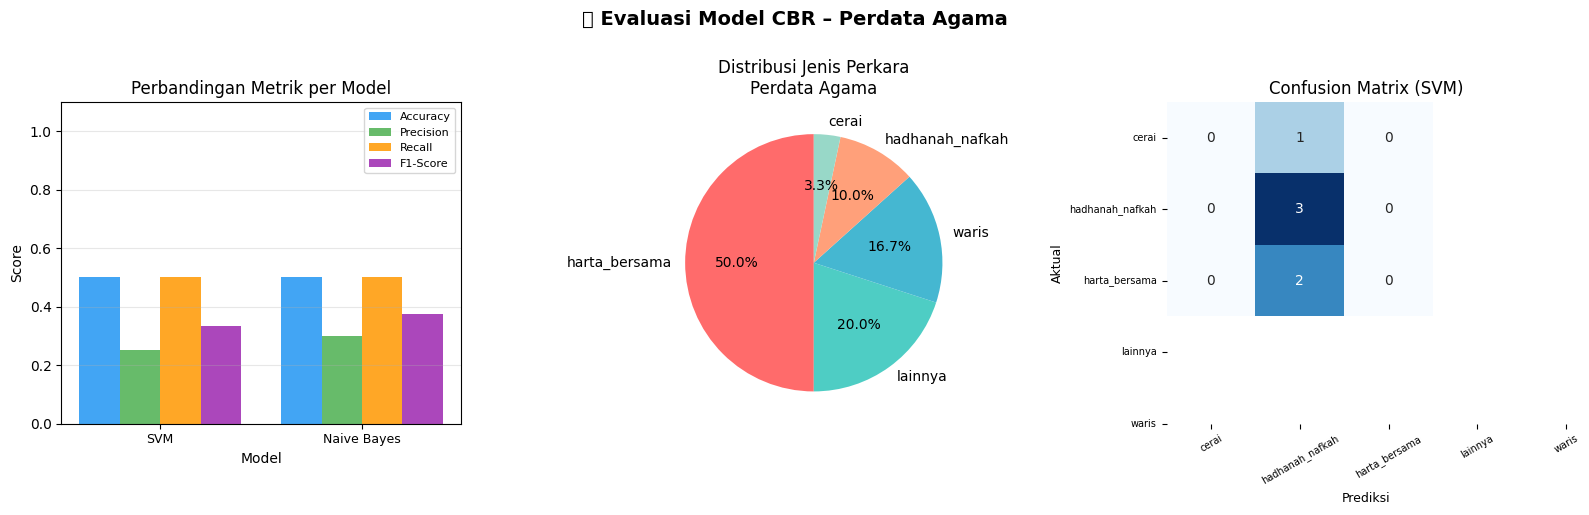

✅ Chart disimpan ke: /content/drive/MyDrive/CBRdimas/data/results/evaluation_chart.png


In [25]:
# ── Visualisasi Perbandingan Model ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('📊 Evaluasi Model CBR – Perdata Agama', fontsize=14, fontweight='bold', y=1.02)

# 1. Bar Chart: Perbandingan Metrik
ax1 = axes[0]
x = np.arange(len(df_metrics['Model']))
width = 0.2
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, (col, color) in enumerate(zip(metrics_cols, colors)):
    ax1.bar(x + i*width, df_metrics[col], width, label=col, color=color, alpha=0.85)

ax1.set_xlabel('Model')
ax1.set_ylabel('Score')
ax1.set_title('Perbandingan Metrik per Model')
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(['SVM', 'Naive Bayes'], fontsize=9)
ax1.set_ylim(0, 1.1)
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# 2. Distribusi Jenis Perkara
ax2 = axes[1]
label_counts = df['label'].value_counts()
wedge_colors = ['#FF6B6B','#4ECDC4','#45B7D1','#FFA07A','#98D8C8']
ax2.pie(
    label_counts.values,
    labels=label_counts.index,
    autopct='%1.1f%%',
    colors=wedge_colors[:len(label_counts)],
    startangle=90
)
ax2.set_title('Distribusi Jenis Perkara\nPerdata Agama')

# 3. Confusion Matrix SVM
ax3 = axes[2]
cm = confusion_matrix(y_test, y_pred_svm)
if cm.size > 1:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=ax3, cbar=False)
    ax3.set_xlabel('Prediksi', fontsize=9)
    ax3.set_ylabel('Aktual', fontsize=9)
    ax3.set_title('Confusion Matrix (SVM)')
    plt.setp(ax3.get_xticklabels(), rotation=30, fontsize=7)
    plt.setp(ax3.get_yticklabels(), rotation=0, fontsize=7)
else:
    ax3.text(0.5, 0.5, 'Data test terlalu kecil\nuntuk confusion matrix',
             ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('Confusion Matrix (SVM)')

plt.tight_layout()
viz_path = DATA_RES / 'evaluation_chart.png'
plt.savefig(viz_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'✅ Chart disimpan ke: {viz_path}')

In [26]:
# ── Analisis Kegagalan (Error Analysis) ──────────────────────────────────────
print('🔍 Analisis Kegagalan Model (Rejection Analysis)')
print('='*60)

# Identifikasi kasus yang salah prediksi (SVM)
test_df = df.iloc[idx_test].copy()
test_df['pred_svm'] = le.inverse_transform(y_pred_svm)
test_df['pred_nb']  = le.inverse_transform(y_pred_nb)
test_df['true_label_str'] = le.inverse_transform(y_test)

errors_svm = test_df[test_df['pred_svm'] != test_df['true_label_str']]
errors_nb  = test_df[test_df['pred_nb']  != test_df['true_label_str']]

print(f'\n📊 SVM  : {len(errors_svm)} dari {len(test_df)} kasus salah prediksi ({len(errors_svm)/len(test_df)*100:.1f}%)')
print(f'📊 NB   : {len(errors_nb)} dari {len(test_df)} kasus salah prediksi ({len(errors_nb)/len(test_df)*100:.1f}%)')

if len(errors_svm) > 0:
    print(f'\n🔴 Kasus salah prediksi SVM:')
    for _, row in errors_svm.iterrows():
        print(f'   [{row["case_id"]}] Aktual: {row["true_label_str"]} → Prediksi: {row["pred_svm"]}')
        print(f'   Teks: {row["ringkasan_fakta"][:100]}...')

print('\n💡 Rekomendasi Perbaikan:')
print('   1. Tambah data training untuk label dengan jumlah kecil (oversampling/SMOTE)')
print('   2. Tingkatkan fitur teks: bigram, trigram, atau word embedding')
print('   3. Coba model transformer (IndoBERT) untuk representasi kontekstual')
print('   4. Tambah threshold kemiripan untuk menolak query yang terlalu berbeda (rejection)')
print('   5. Gunakan k-fold cross validation untuk evaluasi yang lebih robust')

🔍 Analisis Kegagalan Model (Rejection Analysis)

📊 SVM  : 3 dari 6 kasus salah prediksi (50.0%)
📊 NB   : 3 dari 6 kasus salah prediksi (50.0%)

🔴 Kasus salah prediksi SVM:
   [case_028] Aktual: hadhanah_nafkah → Prediksi: harta_bersama
   Teks: jahe telah memberikan putusan nomor 56/pdt.g/2023/pn kbj, tanggal 31 oktober 2023, yang amarnya seba...
   [case_016] Aktual: waris → Prediksi: harta_bersama
   Teks: n-alasannya telah diberitahukan kepada pihak lawan dengan saksama, diajukan dalam tenggang waktu dan...
   [case_024] Aktual: waris → Prediksi: harta_bersama
   Teks: telah diberitahukan kepada pihak lawan dengan saksama, diajukan dalam tenggang waktu dan dengan cara...

💡 Rekomendasi Perbaikan:
   1. Tambah data training untuk label dengan jumlah kecil (oversampling/SMOTE)
   2. Tingkatkan fitur teks: bigram, trigram, atau word embedding
   3. Coba model transformer (IndoBERT) untuk representasi kontekstual
   4. Tambah threshold kemiripan untuk menolak query yang terlalu berbeda 

---
# ✅ Revisi & Retain (Opsional)
> Tambahkan kasus baru yang terbukti solusinya tepat ke dalam case base

In [27]:
# ── Fungsi Revisi & Retain ────────────────────────────────────────────────────
def retain_case(new_case: dict) -> None:
    """
    Tambahkan kasus baru yang telah terbukti solusinya ke dalam case base.

    Parameters
    ----------
    new_case : dict dengan keys:
        - text_full      : teks lengkap kasus
        - amar_putusan   : solusi / amar putusan yang benar
        - jenis_perkara  : jenis perkara
        - no_perkara     : nomor perkara
    """
    global df, tfidf_matrix, tfidf_vectorizer

    # Generate case_id baru
    new_id = f'case_{len(df)+1:03d}_retained'

    # Preprocessing
    clean = clean_text(new_case.get('text_full', ''))

    # Simpan file txt
    (DATA_RAW / f'{new_id}.txt').write_text(clean, encoding='utf-8')

    # Tambah ke dataframe
    new_row = {
        'case_id'        : new_id,
        'no_perkara'     : new_case.get('no_perkara', 'RETAINED'),
        'tanggal'        : datetime.now().strftime('%Y-%m-%d'),
        'jenis_perkara'  : new_case.get('jenis_perkara', 'perdata agama lainnya'),
        'label'          : classify_label(new_case.get('jenis_perkara', '')),
        'amar_putusan'   : new_case.get('amar_putusan', ''),
        'ringkasan_fakta': clean[:400],
        'text_full'      : clean[:2000],
        'text_combined'  : clean,
        'word_count'     : len(clean.split()),
    }

    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

    # Update TF-IDF matrix
    tfidf_matrix = tfidf_vectorizer.transform(df['text_combined'].fillna(''))

    # Update case solutions
    case_solutions[new_id] = new_case.get('amar_putusan', '')

    # Simpan ulang CSV
    df.to_csv(DATA_PROC / 'cases.csv', index=False, encoding='utf-8-sig')

    print(f'✅ Kasus {new_id} berhasil ditambahkan ke case base!')
    print(f'   Total kasus: {len(df)}')
    logger.info(f'[RETAIN] Kasus baru ditambahkan: {new_id}')


# ── Contoh Penggunaan Retain ──────────────────────────────────────────────────
contoh_kasus_baru = {
    'no_perkara'    : '999/Pdt.G/2024/PA.XXX',
    'jenis_perkara' : 'cerai gugat',
    'text_full'     : 'penggugat menggugat cerai tergugat karena tergugat meninggalkan penggugat tanpa alasan jelas selama 2 tahun serta tidak memberikan nafkah lahir maupun batin',
    'amar_putusan'  : 'mengabulkan gugatan penggugat, menjatuhkan talak satu bain dari tergugat kepada penggugat'
}

print('🔄 Menambahkan kasus baru ke case base (Revisi & Retain)...')
retain_case(contoh_kasus_baru)
print(f'\n📊 Case base sekarang berisi {len(df)} kasus')

🔄 Menambahkan kasus baru ke case base (Revisi & Retain)...
✅ Kasus case_031_retained berhasil ditambahkan ke case base!
   Total kasus: 31

📊 Case base sekarang berisi 31 kasus


---
# ☁️ Sinkronisasi Output ke Google Drive
> Salin semua file hasil (CSV, JSON, PNG, log) ke Google Drive.
Jalankan setelah semua tahap selesai.


In [28]:
# ── Sinkronisasi Semua Output ke Google Drive ─────────────────────────────────
import shutil

def sync_to_drive(src: Path, dst_dir: Path, label: str = '') -> None:
    """Salin file src ke dst_dir di Google Drive jika src ada."""
    if src.exists():
        dst = dst_dir / src.name
        shutil.copy2(str(src), str(dst))
        tag = f'[{label}] ' if label else ''
        print(f'   ✅ {tag}{src.name} → {dst}')
    else:
        print(f'   ⚠️  File tidak ditemukan (belum dibuat?): {src}')

print('☁️  Sinkronisasi ke Google Drive...')
print('─'*60)

# Processed
print('📁 data/processed/')
for fname in ['cases.csv', 'cases.json', 'cases_features.csv']:
    sync_to_drive(DATA_PROC / fname, GDRIVE_DIRS['processed'], 'processed')

# Eval
print('\n📁 data/eval/')
for fname in ['queries.json', 'retrieval_metrics.csv', 'prediction_metrics.csv']:
    sync_to_drive(DATA_EVAL / fname, GDRIVE_DIRS['eval'], 'eval')

# Results
print('\n📁 data/results/')
for fname in ['predictions.csv', 'evaluation_chart.png']:
    sync_to_drive(DATA_RES / fname, GDRIVE_DIRS['results'], 'results')

# Logs
print('\n📁 logs/')
sync_to_drive(LOGS_DIR / 'cleaning.log', GDRIVE_DIRS['logs'], 'logs')

# Raw texts
print('\n📁 data/raw/ (semua .txt)')
raw_files = list(DATA_RAW.glob('*.txt'))
for f in raw_files:
    sync_to_drive(f, GDRIVE_DIRS['raw'], 'raw')
if not raw_files:
    print('   ⚠️  Belum ada file .txt di data/raw/')

print('─'*60)
print(f'✅ Sinkronisasi selesai! Semua output tersimpan di:')
print(f'   {GDRIVE_PROJECT}')


☁️  Sinkronisasi ke Google Drive...
────────────────────────────────────────────────────────────
📁 data/processed/


SameFileError: '/content/drive/MyDrive/CBRdimas/data/processed/cases.csv' and '/content/drive/MyDrive/CBRdimas/data/processed/cases.csv' are the same file

---
# 📋 Ringkasan Akhir Proyek

In [29]:
# ── Ringkasan Final ───────────────────────────────────────────────────────────
print('='*65)
print('  ✅ RINGKASAN PROYEK CBR – PERDATA AGAMA')
print('='*65)
print(f'  📚 Domain         : Perdata Agama (Pengadilan Agama RI)')
print(f'  📄 Total Kasus    : {len(df)}')
print(f'  🏷️  Jenis Perkara  : {df["jenis_perkara"].nunique()} kategori')
print(f'  🔢 Fitur TF-IDF   : {tfidf_matrix.shape[1]} fitur')
print()
print('  MODEL PERFORMANCE (Test Set):')
print(f'  TF-IDF + SVM  → F1: {f1_svm:.4f} | Acc: {acc_svm:.4f}')
print(f'  TF-IDF + NB   → F1: {f1_nb:.4f}  | Acc: {acc_nb:.4f}')
print(f'  Retrieval Hit@5    : {hit_at_5:.4f} ({hit_at_5*100:.1f}%)')
print()
print('  OUTPUT FILES:')
print(f'  📂 {DATA_RAW}          ← teks bersih per kasus')
print(f'  📄 {DATA_PROC}/cases.csv    ← representasi terstruktur')
print(f'  📄 {DATA_PROC}/cases.json   ← representasi JSON')
print(f'  📊 {DATA_EVAL}/retrieval_metrics.csv')
print(f'  🎯 {DATA_RES}/predictions.csv')
print(f'  📈 {DATA_RES}/evaluation_chart.png')
print(f'  📋 {LOGS_DIR}/cleaning.log')
print('='*65)

  ✅ RINGKASAN PROYEK CBR – PERDATA AGAMA
  📚 Domain         : Perdata Agama (Pengadilan Agama RI)
  📄 Total Kasus    : 31
  🏷️  Jenis Perkara  : 7 kategori
  🔢 Fitur TF-IDF   : 4728 fitur

  MODEL PERFORMANCE (Test Set):
  TF-IDF + SVM  → F1: 0.3333 | Acc: 0.5000
  TF-IDF + NB   → F1: 0.3750  | Acc: 0.5000
  Retrieval Hit@5    : 0.9000 (90.0%)

  OUTPUT FILES:
  📂 /content/drive/MyDrive/CBRdimas/data/raw          ← teks bersih per kasus
  📄 /content/drive/MyDrive/CBRdimas/data/processed/cases.csv    ← representasi terstruktur
  📄 /content/drive/MyDrive/CBRdimas/data/processed/cases.json   ← representasi JSON
  📊 /content/drive/MyDrive/CBRdimas/data/eval/retrieval_metrics.csv
  🎯 /content/drive/MyDrive/CBRdimas/data/results/predictions.csv
  📈 /content/drive/MyDrive/CBRdimas/data/results/evaluation_chart.png
  📋 /content/drive/MyDrive/CBRdimas/logs/cleaning.log
